In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib

print("Done")


Done


In [2]:
# Load Dataset

df = pd.read_csv(
    "Modelling_data.csv",
    dtype={"StateHoliday": str}
) 

In [3]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,Promo2SinceWeek,...,Year,Month,Day,WeekOFYear,Quarter,IsWeekend,CompetitionOpenDurationMonths,IsSunday,IsSaturday,OpenOnSunday
count,844338.000000,844338.000000,844338.000000,844338.000000,844338.0,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,...,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000,844338.000000
mean,558.421374,3.520350,6955.959134,762.777166,1.0,0.446356,0.193578,5458.156627,0.498670,23.254177,...,2013.831945,5.845774,15.835706,23.646946,2.296006,0.174865,63.851518,0.004255,0.170609,0.004255
std,321.730861,1.723712,3103.815515,401.194153,0.0,0.497114,0.395102,7799.457083,0.499999,9.957387,...,0.777271,3.323959,8.683392,14.389931,1.083494,0.379852,58.873037,0.065095,0.376168,0.065095
min,1.000000,1.000000,46.000000,8.000000,1.0,0.000000,0.000000,20.000000,0.000000,1.000000,...,2013.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,0.000000,22.000000,...,2013.000000,3.000000,8.000000,11.000000,1.000000,0.000000,29.000000,0.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,1.0,0.000000,0.000000,2330.000000,0.000000,23.254177,...,2014.000000,6.000000,16.000000,23.000000,2.000000,0.000000,63.000000,0.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.0,1.000000,0.000000,6880.000000,1.000000,23.254177,...,2014.000000,8.000000,23.000000,35.000000,3.000000,0.000000,81.000000,0.000000,0.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,1.000000,50.000000,...,2015.000000,12.000000,31.000000,52.000000,4.000000,1.000000,1386.000000,1.000000,1.000000,1.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Store                          844338 non-null  int64  
 1   DayOfWeek                      844338 non-null  int64  
 2   Date                           844338 non-null  str    
 3   Sales                          844338 non-null  int64  
 4   Customers                      844338 non-null  int64  
 5   Open                           844338 non-null  int64  
 6   Promo                          844338 non-null  int64  
 7   StateHoliday                   844338 non-null  str    
 8   SchoolHoliday                  844338 non-null  int64  
 9   StoreType                      844338 non-null  str    
 10  Assortment                     844338 non-null  str    
 11  CompetitionDistance            844338 non-null  float64
 12  Promo2                         844338 non

## __Modelling__
Since this is a forecasting problem, the dataset is splitted chronologically. Older dates are used as training data, while newer dates are reserved as test data. This approach better simulats a real forecasting scenario,where the model learns from historical observations and predicts future sales.

In [5]:
# sort dataset by date first

df = df.sort_values("Date")

In [6]:
# Features and Target 
X = df.drop(["Sales"], axis = 1)
y = df["Sales"]

In [7]:
# Chronological split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
# Drop raw Date column before start modelling
X_train = X_train.drop("Date", axis =1)
X_test = X_test.drop("Date", axis = 1)

In [9]:
# convert categorical variable into numerical dummy variables
X_train = pd.get_dummies(X_train, drop_first = True)
X_test = pd.get_dummies(X_test, drop_first = True)

# Align train and test columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

## __First baseline model__ __Gradiente Boosting__

In [10]:
# GradienteBoostingRegressor model

model = GradientBoostingRegressor(random_state = 42)

model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [11]:
# predictions 
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score", r2)
      

MAE: 800.3566844502584
RMSE: 1120.7636354295587
R2 Score 0.8661588346393562


In [12]:
# Feature Importance analysis

feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending = False)

print(feature_importance.head(15))

Customers                0.818142
Promo                    0.046284
StoreType_d              0.037788
CompetitionDistance      0.027036
Assortment_b             0.022644
StoreType_b              0.009985
DayOfWeek                0.007758
WeekOFYear               0.007236
Promo2SinceYear          0.006436
Assortment_c             0.004299
Day                      0.002696
Month                    0.002582
Promo2SinceWeek          0.002096
Store                    0.001820
PromoInterval_NoPromo    0.000937
dtype: float64


Text(0, 0.5, 'Features')

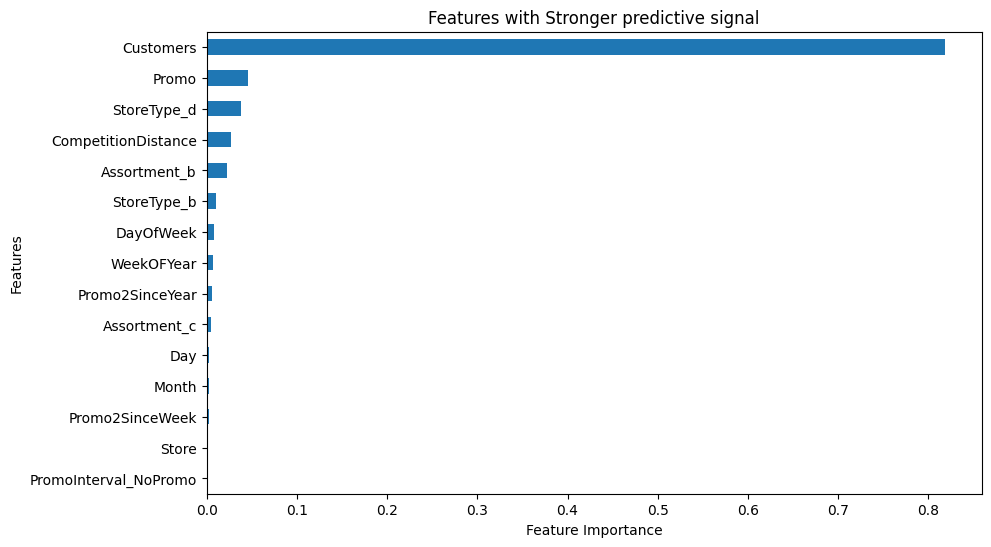

In [13]:
# Plot visually the feature importance

feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10,6),
    
    )
plt.title("Features with Stronger predictive signal")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

### Model Feature Importance Observation

The feature importance analysis reveals that customer volume is by far the strongest predictor of sales performance, followed by promotional activity and store-related characteristics. Temporal engineered features such as DayOfWeek, WeekOfYear, Month, and promotion duration variables also contributed predictive signal, confirming the presence of seasonality and recurring purchasing behavior patterns within the dataset.

Additionally, competition-related variables demonstrated meaningful influence on sales forecasting, suggesting that local market dynamics affect long-term store performance. The results validate the effectiveness of the feature engineering process and indicate that the model successfully captured both operational and temporal business patterns relevant for forecasting future sales.

## __Second Model__ __Random Forest__

In [14]:
# RandomForestRegressor Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [15]:
# Predictions

y_pred = rf_model.predict(X_test)

# Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:",r2)


MAE: 560.6947884540958
RMSE: 807.5445838871581
R2: 0.9305144236304205


In [16]:
# Features with the strongest signal in this model 

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index= X_train.columns
).sort_values(ascending=False)

print(rf_importance.head(15))

Customers                        0.780476
StoreType_d                      0.043713
CompetitionDistance              0.042870
Promo                            0.032967
Assortment_b                     0.020414
Store                            0.018670
StoreType_b                      0.011099
Promo2SinceYear                  0.009799
CompetitionOpenDurationMonths    0.008425
DayOfWeek                        0.006918
Promo2SinceWeek                  0.006349
WeekOFYear                       0.004623
Assortment_c                     0.003077
Month                            0.001731
StoreType_c                      0.001548
dtype: float64


Text(0, 0.5, 'Features')

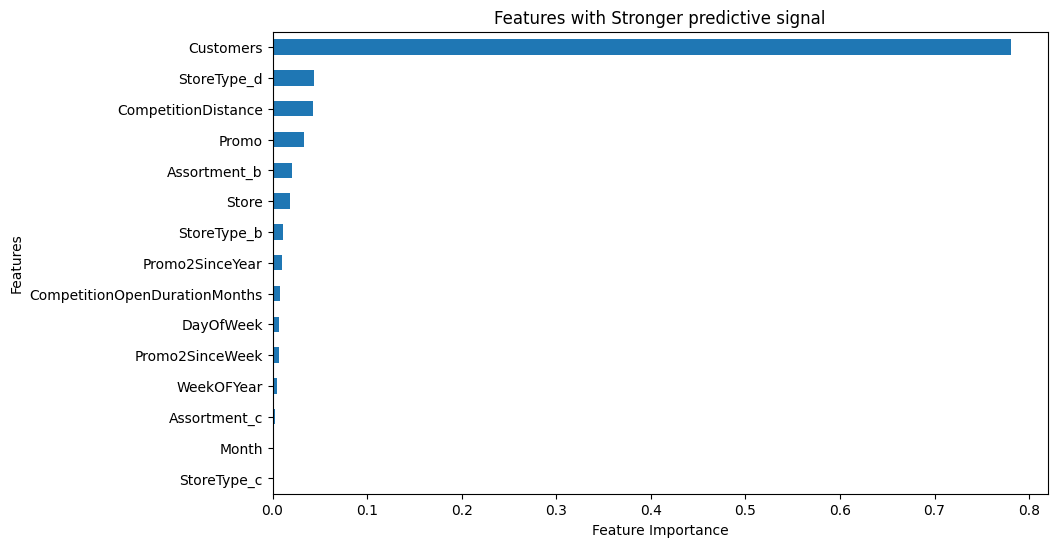

In [17]:
# Plot visually the feature importance

rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10,6),
    
    )
plt.title("Features with Stronger predictive signal")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

## __Third Model__  __XGBoosst__

In [18]:
xgb_model = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.1,
    max_depth = 8,
    subsample=0.8,
    colsample_bytree = 0.8,
    random_state = 42
)

xgb_model.fit(X_train, y_train)
    
    

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [19]:
# Predictions

y_pred = xgb_model.predict(X_test)

# Evaluation mwtrics

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:",mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 426.48516845703125
RMSE: 615.648971614507
R2: 0.9596142768859863


In [20]:
# Features with the strongest signal in this model 

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index= X_train.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

Customers                0.244114
StoreType_b              0.189606
Assortment_b             0.160173
StoreType_d              0.134937
Promo                    0.048943
CompetitionDistance      0.020797
Promo2                   0.019067
Promo2SinceYear          0.016485
PromoInterval_NoPromo    0.016262
Assortment_c             0.015809
DayOfWeek                0.012068
StoreType_c              0.012053
IsSaturday               0.011428
Promo2SinceWeek          0.011321
Store                    0.010346
dtype: float32


Text(0, 0.5, 'Features')

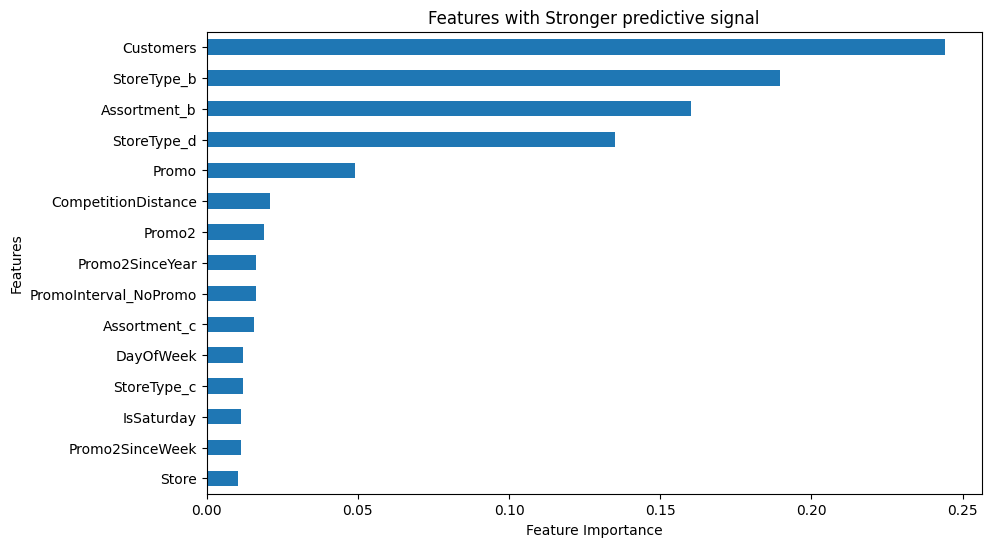

In [21]:
# Plot visually the feature importance

xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10,6),
    
    )
plt.title("Features with Stronger predictive signal")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

## __Final Model Comparison__

In [22]:
# comparison data frame

comparison_df = pd.DataFrame({
    "Model" : [ "Baseline GB", "Random Forest", "XGBoost"],
    "MAE" : [800.35,560.69,436.49],
    "RMSE" : [1120.76, 807.54, 615.64],
    "R2 Score" : [0.866, 0.931, 0.959]
})

comparison_df

,Model,MAE,RMSE,R2 Score
0,Baseline GB,800.35,1120.76,0.866
1,Random Forest,560.69,807.54,0.931
2,XGBoost,436.49,615.64,0.959


#### __Conclusion__

The XGBoost model achieved the strongest forecasting performance among all evaluated models, producing the lowest prediction error and highest explanatory power. compared to the Baseline and  Random Forest models, XGBoost demonstated superior capability in capturing nonlinear relationships between promotion activity, customer traffic, temporal seasonality, and store-leavel operation characteristics.

The progressive improvement in MAE, RMSE and R2 scores across models highlights the effectiveness of ensembled-based machine learning techniques for retail sales forecasting tasks. Due to its high predictive accuracy and state generalization performance on unseen future sales data, XGBoost was selected as the final forecasting model for this project.

In [23]:
# Saving the Selected Model in order to use it in the forecasting analysis notebook

# joblib.dump(xgb_model,"xgboost_sales_model.pkl")